In [29]:
import pandas as pd
import numpy as np
import os
import sys

In [ ]:
path = "C:/..." # your csv path

df = pd.read_csv(path, encoding='cp949')
df = df.dropna(axis=0, how='all')

In [31]:
df

,B11,Trace0,Trace1,Trace2,Unnamed: 4,B12,Trace0.1,Trace1.1,Trace2.1,Unnamed: 9,...,Unnamed: 34,1stDW,Trace0.7,Trace1.7,Trace2.7,Unnamed: 39,2ndEtOH,Trace0.8,Trace1.8,Trace2.8
0,342.000,4.000,482.923,525.700,NaN,342.000,4.000,482.923,525.700,NaN,...,NaN,342.000,0.078,375.200,417.533,NaN,342.000,-0.008,376.867,408.633
1,342.472,4.000,483.538,537.233,NaN,342.472,4.000,483.538,537.233,NaN,...,NaN,342.472,0.068,376.700,428.833,NaN,342.472,-0.009,379.300,419.933
2,342.944,2.417,486.308,545.300,NaN,342.944,4.000,486.308,545.300,NaN,...,NaN,342.944,0.052,378.767,435.767,NaN,342.944,-0.008,382.167,429.467
3,343.415,1.006,484.538,551.000,NaN,343.415,1.437,484.538,551.000,NaN,...,NaN,343.415,0.050,378.800,440.433,NaN,343.415,-0.001,383.600,436.200
4,343.887,0.757,482.923,553.433,NaN,343.887,0.971,482.923,553.433,NaN,...,NaN,343.887,0.059,377.933,444.133,NaN,343.887,0.008,383.733,440.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,1078.176,-2.293,482.846,482.600,NaN,-1078.176,2.375,482.846,482.600,NaN,...,NaN,1078.176,4.000,373.033,377.600,NaN,1078.176,-0.586,368.067,368.300
2044,1078.388,4.000,482.692,483.400,NaN,1078.388,4.000,482.692,483.400,NaN,...,NaN,1078.388,4.000,372.433,377.767,NaN,1078.388,4.000,367.467,367.233
2045,1078.600,-1.764,485.308,484.433,NaN,-1078.600,1.842,485.308,484.433,NaN,...,NaN,1078.600,4.000,374.567,378.567,NaN,1078.600,-0.084,367.967,369.533
2046,1078.811,-1.471,487.077,485.300,NaN,-1078.811,1.537,487.077,485.300,NaN,...,NaN,1078.811,4.000,377.667,378.067,NaN,1078.811,0.206,368.333,371.600


In [32]:
df = df.dropna(axis=1, how='all')
df = df.dropna(axis=0, how='all')

In [33]:
df

,B11,Trace0,Trace1,Trace2,B12,Trace0.1,Trace1.1,Trace2.1,B21,Trace0.2,...,Trace1.6,Trace2.6,1stDW,Trace0.7,Trace1.7,Trace2.7,2ndEtOH,Trace0.8,Trace1.8,Trace2.8
0,342.000,4.000,482.923,525.700,342.000,4.000,482.923,525.700,342.000,4.000,...,426.767,455.033,342.000,0.078,375.200,417.533,342.000,-0.008,376.867,408.633
1,342.472,4.000,483.538,537.233,342.472,4.000,483.538,537.233,342.472,4.000,...,430.200,465.233,342.472,0.068,376.700,428.833,342.472,-0.009,379.300,419.933
2,342.944,2.417,486.308,545.300,342.944,4.000,486.308,545.300,342.944,4.000,...,434.667,473.100,342.944,0.052,378.767,435.767,342.944,-0.008,382.167,429.467
3,343.415,1.006,484.538,551.000,343.415,1.437,484.538,551.000,343.415,4.000,...,438.167,478.200,343.415,0.050,378.800,440.433,343.415,-0.001,383.600,436.200
4,343.887,0.757,482.923,553.433,343.887,0.971,482.923,553.433,343.887,4.000,...,438.700,480.733,343.887,0.059,377.933,444.133,343.887,0.008,383.733,440.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,1078.176,-2.293,482.846,482.600,-1078.176,2.375,482.846,482.600,1078.176,-2.412,...,408.600,413.633,1078.176,4.000,373.033,377.600,1078.176,-0.586,368.067,368.300
2044,1078.388,4.000,482.692,483.400,1078.388,4.000,482.692,483.400,1078.388,4.000,...,408.367,413.700,1078.388,4.000,372.433,377.767,1078.388,4.000,367.467,367.233
2045,1078.600,-1.764,485.308,484.433,-1078.600,1.842,485.308,484.433,1078.600,-1.868,...,410.167,414.700,1078.600,4.000,374.567,378.567,1078.600,-0.084,367.967,369.533
2046,1078.811,-1.471,487.077,485.300,-1078.811,1.537,487.077,485.300,1078.811,-1.568,...,413.167,415.267,1078.811,4.000,377.667,378.067,1078.811,0.206,368.333,371.600


In [36]:
# column 이름 변경, Trace0.n -> Absorbance

for i in range(9):
    df.rename(columns={f'Trace0.{i}': f'Absorbance{i}'}, inplace=True)
df.rename(columns={f'Trace0': f'Absorbance{0}'}, inplace=True)

In [37]:
df

,B11,Absorbance0,Trace1,Trace2,B12,Absorbance1,Trace1.1,Trace2.1,B21,Absorbance2,...,Trace1.6,Trace2.6,1stDW,Absorbance7,Trace1.7,Trace2.7,2ndEtOH,Absorbance8,Trace1.8,Trace2.8
0,342.000,4.000,482.923,525.700,342.000,4.000,482.923,525.700,342.000,4.000,...,426.767,455.033,342.000,0.078,375.200,417.533,342.000,-0.008,376.867,408.633
1,342.472,4.000,483.538,537.233,342.472,4.000,483.538,537.233,342.472,4.000,...,430.200,465.233,342.472,0.068,376.700,428.833,342.472,-0.009,379.300,419.933
2,342.944,2.417,486.308,545.300,342.944,4.000,486.308,545.300,342.944,4.000,...,434.667,473.100,342.944,0.052,378.767,435.767,342.944,-0.008,382.167,429.467
3,343.415,1.006,484.538,551.000,343.415,1.437,484.538,551.000,343.415,4.000,...,438.167,478.200,343.415,0.050,378.800,440.433,343.415,-0.001,383.600,436.200
4,343.887,0.757,482.923,553.433,343.887,0.971,482.923,553.433,343.887,4.000,...,438.700,480.733,343.887,0.059,377.933,444.133,343.887,0.008,383.733,440.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,1078.176,-2.293,482.846,482.600,-1078.176,2.375,482.846,482.600,1078.176,-2.412,...,408.600,413.633,1078.176,4.000,373.033,377.600,1078.176,-0.586,368.067,368.300
2044,1078.388,4.000,482.692,483.400,1078.388,4.000,482.692,483.400,1078.388,4.000,...,408.367,413.700,1078.388,4.000,372.433,377.767,1078.388,4.000,367.467,367.233
2045,1078.600,-1.764,485.308,484.433,-1078.600,1.842,485.308,484.433,1078.600,-1.868,...,410.167,414.700,1078.600,4.000,374.567,378.567,1078.600,-0.084,367.967,369.533
2046,1078.811,-1.471,487.077,485.300,-1078.811,1.537,487.077,485.300,1078.811,-1.568,...,413.167,415.267,1078.811,4.000,377.667,378.067,1078.811,0.206,368.333,371.600


In [44]:
# column names

df.columns

Index(['B11', 'Absorbance0', 'Trace1', 'Trace2', 'B12', 'Absorbance1',
       'Trace1.1', 'Trace2.1', 'B21', 'Absorbance2', 'Trace1.2', 'Trace2.2',
       'Y11', 'Absorbance3', 'Trace1.3', 'Trace2.3', 'Y12', 'Absorbance4',
       'Trace1.4', 'Trace2.4', 'Y21', 'Absorbance5', 'Trace1.5', 'Trace2.5',
       'M11', 'Absorbance6', 'Trace1.6', 'Trace2.6', '1stDW', 'Absorbance7',
       'Trace1.7', 'Trace2.7', '2ndEtOH', 'Absorbance8', 'Trace1.8',
       'Trace2.8'],
      dtype='object')

In [45]:
wavelength = df['B11'].values
B = df['Absorbance0'].values
Y = df['Absorbance3'].values
M = df['Absorbance6'].values

In [46]:
# cut off wavelength and b y m, 450nm < wavelength < 600nm

cut_off = (wavelength > 400) & (wavelength < 700)
wavelength = wavelength[cut_off]
B = B[cut_off]
Y = Y[cut_off]
M = M[cut_off]

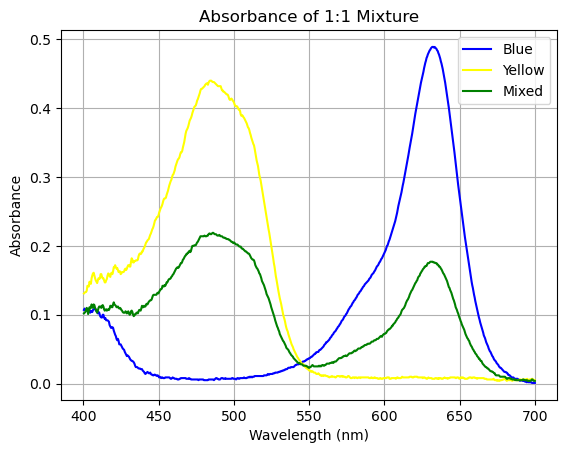

In [48]:
# ploting B Y M with wavelength
import matplotlib.pyplot as plt

plt.plot(wavelength, B, label='Blue', color='blue')
plt.plot(wavelength, Y, label='Yellow', color='yellow')
plt.plot(wavelength, M, label='Mixed', color='green')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')
plt.title('Absorbance of 1:1 Mixture')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# max absorbance of B Y

B_max = np.max(B)
Y_max = np.max(Y)
B_max_index = np.argmax(B)
Y_max_index = np.argmax(Y)
B_max_wavelength = wavelength[B_max_index]
Y_max_wavelength = wavelength[Y_max_index]
print(f'B_max: {B_max}, Y_max: {Y_max}')
print(f'B_max_wavelength: {B_max_wavelength}, Y_max_wavelength: {Y_max_wavelength}')

B_max: 0.489, Y_max: 0.44
B_max_wavelength: 631.686, Y_max_wavelength: 484.065


In [55]:
# g/mol and mg/L to mol/L

B_molar_mass = 792.9  # g/mol
Y_molar_mass = 452.4  # g/mol
B_conc = 6.67  # mg/L
Y_conc = 6.67  # mg/L
B_conc = B_conc / B_molar_mass * 1e-3  # mol/L
Y_conc = Y_conc / Y_molar_mass * 1e-3  # mol/L

print(f'B concentration: {B_conc}, Y concentration: {Y_conc} (mol/L)')

B concentration: 8.412157901374701e-06, Y concentration: 1.4743589743589745e-05 (mol/L)


In [56]:
df.columns

Index(['B11', 'Absorbance0', 'Trace1', 'Trace2', 'B12', 'Absorbance1',
       'Trace1.1', 'Trace2.1', 'B21', 'Absorbance2', 'Trace1.2', 'Trace2.2',
       'Y11', 'Absorbance3', 'Trace1.3', 'Trace2.3', 'Y12', 'Absorbance4',
       'Trace1.4', 'Trace2.4', 'Y21', 'Absorbance5', 'Trace1.5', 'Trace2.5',
       'M11', 'Absorbance6', 'Trace1.6', 'Trace2.6', '1stDW', 'Absorbance7',
       'Trace1.7', 'Trace2.7', '2ndEtOH', 'Absorbance8', 'Trace1.8',
       'Trace2.8'],
      dtype='object')

In [63]:
B12 = df['Absorbance1'].values[cut_off]
B21 = df['Absorbance2'].values[cut_off]
Y12 = df['Absorbance4'].values[cut_off]
Y21 = df['Absorbance5'].values[cut_off]

B12max = B12[B_max_index]
B21max = B21[B_max_index]
Y12max = Y12[Y_max_index]
Y21max = Y21[Y_max_index]

B12max, B21max, Y12max, Y21max

(0.345, 0.674, 0.251, 0.609)

In [83]:
# linear regression between conc and absorbance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

conc_y = np.array([0.5*Y_conc, (1/3)*Y_conc, (2/3)*Y_conc])
max_abs_y = np.array([Y_max, Y12max, Y21max])

conc_b = np.array([0.5*B_conc, (1/3)*B_conc, (2/3)*B_conc])
max_abs_b = np.array([B_max, B12max, B21max])

# linear regression for Y
model_y = LinearRegression()
model_y.fit(conc_y.reshape(-1, 1), max_abs_y)
y_pred_y = model_y.predict(conc_y.reshape(-1, 1))
r2_y = r2_score(max_abs_y, y_pred_y)
print(f'Y: slope = {model_y.coef_[0]}, intercept = {model_y.intercept_}, r2 = {r2_y}')
# linear regression for B
model_b = LinearRegression()
model_b.fit(conc_b.reshape(-1, 1), max_abs_b)
y_pred_b = model_b.predict(conc_b.reshape(-1, 1))
r2_b = r2_score(max_abs_b, y_pred_b)
print(f'B: slope = {model_b.coef_[0]}, intercept = {model_b.intercept_}, r2 = {r2_b}')

Y: slope = 72845.21739130435, intercept = -0.1036666666666668, r2 = 0.998960747430448
B: slope = 117330.17991004499, intercept = 0.0091666666666666, r2 = 0.9948499405644539


In [125]:
# mol_absorbance coefficient with 1 cm by beer-lambert law
# A = εlc

b_abs_coef = model_b.coef_[0]
y_abs_coef = model_y.coef_[0]

print(f'B: {np.round(b_abs_coef, -4)}, Y: {np.round(y_abs_coef, -3)} (L/(mol*cm))')

B: 120000.0, Y: 73000.0 (L/(mol*cm))


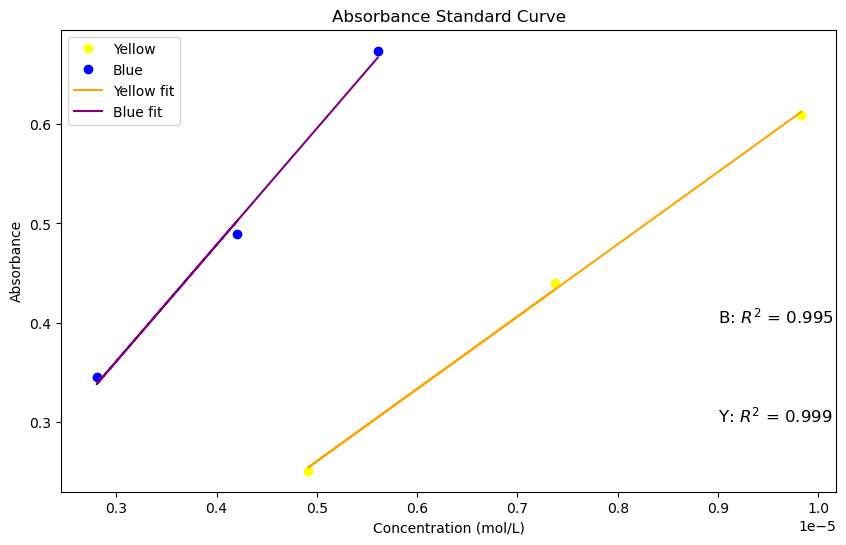

In [134]:
# linear plot with r2 value

plt.figure(figsize=(10, 6))
plt.plot(conc_y, max_abs_y, 'o', label='Yellow', color='yellow')
plt.plot(conc_b, max_abs_b, 'o', label='Blue', color='blue')
plt.plot(conc_y, y_pred_y, label='Yellow fit', color='orange')
plt.plot(conc_b, y_pred_b, label='Blue fit', color='purple')
plt.text(0.9e-5, 0.3, f'Y: $R^2$ = {r2_y:.3f}', fontsize=12, color='black')
plt.text(0.9e-5, 0.4, f'B: $R^2$ = {r2_b:.3f}', fontsize=12, color='black')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('Absorbance')
plt.title('Absorbance Standard Curve')
plt.legend()

In [136]:
# m concentration by y

M = df['Absorbance6'].values
M_bmax = 2*M[B_max_index] # 1:1 mixture
M_ymax = 2*M[Y_max_index] # 1:1 mixture
print(f'M_bmax: {M_bmax}, M_ymax: {M_ymax}')

# m concentration by b 
M_conc_b = (M_bmax - model_b.intercept_) / model_b.coef_[0]
print(f'M concentration by B: {np.round(M_conc_b, 8)} (mol/L)')

# m concentration by y
M_conc_y = (M_ymax - model_y.intercept_) / model_y.coef_[0]
print(f'M concentration by Y: {np.round(M_conc_y, 7)} (mol/L)')

# mixture ratio
M_ratio = M_conc_b / M_conc_y
print(f'Mixture ratio: {np.round(M_ratio, 5)}')

# y, b mol in 1mL M

Y_mol = M_conc_y * 1e3  # mol/mL
B_mol = M_conc_b * 1e3  # mol/mL
print(f'Y mol in 1mL: {np.round(Y_mol, 4)}, B mol in 1mL: {np.round(B_mol, 5)}')

M_bmax: 0.092, M_ymax: 0.206
M concentration by B: 7.1e-07 (mol/L)
M concentration by Y: 4.3e-06 (mol/L)
Mixture ratio: 0.16607
Y mol in 1mL: 0.0043, B mol in 1mL: 0.00071


In [135]:
# m conc b / b conc, m conc y / y conc
M_conc_b_ratio = M_conc_b / B_conc
M_conc_y_ratio = M_conc_y / Y_conc

print(f'M_conc_b_ratio: {np.round(M_conc_b_ratio, 2)}, M_conc_y_ratio: {np.round(M_conc_y_ratio, 2)}')

M_conc_b_ratio: 0.08, M_conc_y_ratio: 0.29


In [114]:
df.columns

Index(['B11', 'Absorbance0', 'Trace1', 'Trace2', 'B12', 'Absorbance1',
       'Trace1.1', 'Trace2.1', 'B21', 'Absorbance2', 'Trace1.2', 'Trace2.2',
       'Y11', 'Absorbance3', 'Trace1.3', 'Trace2.3', 'Y12', 'Absorbance4',
       'Trace1.4', 'Trace2.4', 'Y21', 'Absorbance5', 'Trace1.5', 'Trace2.5',
       'M11', 'Absorbance6', 'Trace1.6', 'Trace2.6', '1stDW', 'Absorbance7',
       'Trace1.7', 'Trace2.7', '2ndEtOH', 'Absorbance8', 'Trace1.8',
       'Trace2.8'],
      dtype='object')

In [116]:
Y_exp2 = df['Absorbance7'].values[cut_off]
B_exp3 = df['Absorbance8'].values[cut_off]

Y_exp2max = Y_exp2[Y_max_index]
B_exp3max = B_exp3[B_max_index]

print(f'Y_exp2max: {Y_exp2max}, B_exp3max: {B_exp3max}')

# concentration by y
Y_conc_exp2 = (Y_exp2max - model_y.intercept_) / model_y.coef_[0]
print(f'Y concentration by Exp2: {np.round(Y_conc_exp2, 7)} (mol/L)')

# concentration by b
B_conc_exp3 = (B_exp3max - model_b.intercept_) / model_b.coef_[0]
print(f'B concentration by Exp3: {np.round(B_conc_exp3, 8)} (mol/L)')

Y_exp2max: 0.133, B_exp3max: 0.104
Y concentration by Exp2: 3.2e-06 (mol/L)
B concentration by Exp3: 8.1e-07 (mol/L)


In [119]:
# recover ratio

Y_recover_ratio = Y_conc_exp2 / M_conc_y
B_recover_ratio = B_conc_exp3 / M_conc_b

print(f'Y recover ratio: {np.round(Y_recover_ratio, 2)}')
print(f'B recover ratio: {np.round(B_recover_ratio, 1)}')

Y recover ratio: 0.76
B recover ratio: 1.1
